# U-Net probe on AudioSet sub-labels

Pick one subsection folder, run separation on a single clip, listen to mix / voice / background.

Edit **`SUB_LABEL`** below and re-run the notebook to try another category.

In [3]:
from pathlib import Path
import sys

import librosa
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.source_separation.infer import load_unet_checkpoint, separate_voice

In [43]:
# --- edit this ---

SUB_LABEL = "Yell"  # folder under datasets/audioset/audio/
CLIP_INDEX = 1  # which .wav in that folder (0 = first)

AUDIO_ROOT = REPO_ROOT / "datasets/audioset/audio"
CKPT_PATH = REPO_ROOT / "checkpoints/unet_run1/unet_voice_sep.pt"

label_dir = AUDIO_ROOT / SUB_LABEL
if not label_dir.is_dir():
    available = sorted(p.name for p in AUDIO_ROOT.iterdir() if p.is_dir())
    raise FileNotFoundError(
        f"No folder {label_dir}\nAvailable: {available[:12]}... ({len(available)} total)"
    )

clips = sorted(p for p in label_dir.glob("*.wav") if p.stat().st_size > 1000)
if not clips:
    raise FileNotFoundError(f"No non-empty wav files in {label_dir}")
if CLIP_INDEX >= len(clips):
    raise IndexError(f"CLIP_INDEX={CLIP_INDEX} but only {len(clips)} clips")

audio_path = clips[CLIP_INDEX]
print(f"Sub-label: {SUB_LABEL}")
print(f"Clip: {audio_path.name} ({audio_path.stat().st_size // 1024} KB)")
print(f"Checkpoint: {CKPT_PATH}")

Sub-label: Yell
Clip: _DimZ1upYMU_0.0s.wav (1068 KB)
Checkpoint: /home/luusamp/crossroads/voice-anonymization/checkpoints/unet_run1/unet_voice_sep.pt


In [44]:
model, config, device = load_unet_checkpoint(CKPT_PATH)
print(f"Device: {device} | sr={config.sample_rate}")

y_mix, sr_in = librosa.load(str(audio_path), sr=None, mono=True)
y_mix = y_mix.astype(np.float32)
print(f"Loaded {len(y_mix) / sr_in:.2f}s @ {sr_in} Hz")

y_voice, y_bg, sr = separate_voice(y_mix, sr_in, model, config, device)
if sr_in != sr:
    y_mix = librosa.resample(y_mix, orig_sr=sr_in, target_sr=sr).astype(np.float32)
print(f"Voice energy ratio: {(np.mean(y_voice**2) / (np.mean(y_mix**2) + 1e-12)):.3f}")

Device: cuda | sr=16000
Loaded 6.20s @ 44100 Hz
Voice energy ratio: 0.583


In [45]:
print("Mix")
display(Audio(y_mix, rate=sr))
print("Estimated voice")
display(Audio(y_voice, rate=sr))
print("Estimated background")
display(Audio(y_bg, rate=sr))

Mix


Estimated voice


Estimated background


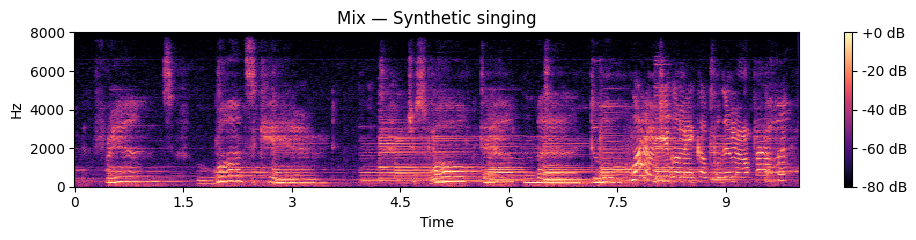

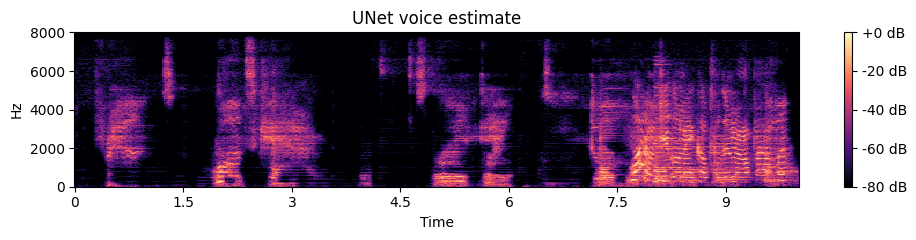

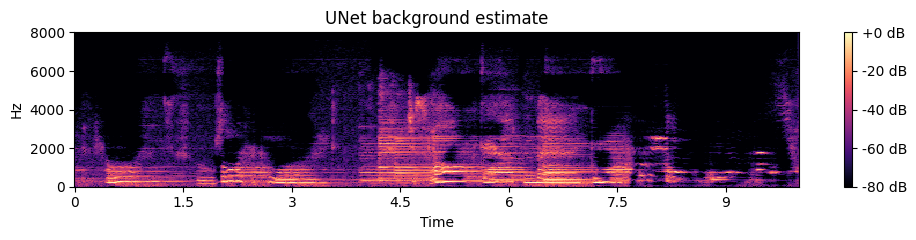

In [42]:
def show_spec(y, title, sr_hz):
    S = np.abs(librosa.stft(y, n_fft=1024, hop_length=256))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    plt.figure(figsize=(10, 2.5))
    librosa.display.specshow(S_db, sr=sr_hz, hop_length=256, x_axis="time", y_axis="hz")
    plt.title(title)
    plt.colorbar(format="%+0.0f dB")
    plt.tight_layout()

show_spec(y_mix, f"Mix — {SUB_LABEL}", sr)
show_spec(y_voice, "UNet voice estimate", sr)
show_spec(y_bg, "UNet background estimate", sr)
plt.show()